# 🍣 Food Attractiveness Rater — v3

โปรเจกต์วิเคราะห์และจัดอันดับ **ความน่ากิน** ของรูปอาหาร โดยเรียนรู้จากรสนิยมการโหวตของมนุษย์จริงๆ

**แหล่งข้อมูล:**
- 📋 **Questionnaire** — 500 คู่เปรียบเทียบ (129 คนโหวต) มีน้ำหนักสูงสุด
- 📸 **Instagram** — 265 คู่เปรียบเทียบ จาก 5 หมวดอาหาร (Burger, Dessert, Pizza, Ramen, Sushi)
- 🤖 **Auto-label** — ~21,904 รูปที่เหลือ label อัตโนมัติด้วย Aesthetic Score

**โมเดล v3 (อัปเกรดจาก v2):**
| | v2 | v3 |
|--|--|--|
| Backbone | EfficientNetV2S | **EfficientNetV2M** |
| Input size | 224px | **260px** |
| Data Augmentation | ❌ | ✅ flip/rotate/zoom/brightness |
| LR Schedule | Constant | **Cosine Decay** |
| Label Smoothing | ❌ | ✅ 0.1 |
| Batch size | 16 | **32** |
| Epochs | 30/20 | **50/30** |


## 0. ติดตั้ง Library

> ⚠️ **ต้องใช้ Python 3.10–3.12** เท่านั้น (TensorFlow ยังไม่รองรับ 3.13+)
>
> **วิธีสร้าง venv บน Linux/WSL2:**
> ```bash
> python3 -m venv .venv && source .venv/bin/activate
> pip install "tensorflow[and-cuda]" scikit-learn matplotlib seaborn pandas numpy tqdm streamlit
> ```


In [1]:
import subprocess, sys

# ── ตรวจสอบ Python version ─────────────────────────────────────────────
major, minor = sys.version_info.major, sys.version_info.minor
print(f'Python version: {major}.{minor}')

if (major, minor) > (3, 12):
    print(f'\n❌ Python {major}.{minor} ยังไม่รองรับ TensorFlow!')
    print('   TensorFlow รองรับเฉพาะ Python 3.10 / 3.11 / 3.12')
    print('\n📌 วิธีแก้ (Windows) — รันใน Terminal แล้วเลือก kernel .venv:')
    print('   > py -3.11 -m venv .venv')
    print('   > .venv\\Scripts\\activate')
    print('   > pip install tensorflow[and-cuda] scikit-learn matplotlib seaborn pandas numpy tqdm')
    raise SystemExit('กรุณาสร้าง venv ด้วย Python 3.11 แล้วเปลี่ยน kernel ใน Jupyter ก่อน')

# ── ติดตั้ง packages ────────────────────────────────────────────────────
print('\nกำลังติดตั้ง packages...')
pkgs = ['tensorflow[and-cuda]', 'scikit-learn', 'matplotlib',
        'seaborn', 'pandas', 'numpy', 'tqdm']
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q'] + pkgs,
    capture_output=True, text=True
)
if result.returncode != 0:
    print(f'⚠  pip warning/error:\n{result.stderr[-500:]}')
else:
    print('✓ ติดตั้ง Library เรียบร้อย')


Python version: 3.12

กำลังติดตั้ง packages...
✓ ติดตั้ง Library เรียบร้อย


## 1. Import Libraries และตั้งค่า GPU


In [2]:
import ctypes, os

_CUDA_LIBS = [
    "/usr/lib/wsl/lib/libcuda.so.1",
    "/home/besstsu/Documents/MachineVision/.venv/lib/python3.12/site-packages/nvidia/cudnn/lib/libcudnn.so.9",
    "/home/besstsu/Documents/MachineVision/.venv/lib/python3.12/site-packages/nvidia/cublas/lib/libcublas.so.12",
    "/home/besstsu/Documents/MachineVision/.venv/lib/python3.12/site-packages/nvidia/cuda_runtime/lib/libcudart.so.12",
    "/home/besstsu/Documents/MachineVision/.venv/lib/python3.12/site-packages/nvidia/cufft/lib/libcufft.so.11",
    "/home/besstsu/Documents/MachineVision/.venv/lib/python3.12/site-packages/nvidia/curand/lib/libcurand.so.10",
    "/home/besstsu/Documents/MachineVision/.venv/lib/python3.12/site-packages/nvidia/cusolver/lib/libcusolver.so.11",
    "/home/besstsu/Documents/MachineVision/.venv/lib/python3.12/site-packages/nvidia/cusparse/lib/libcusparse.so.12",
    "/home/besstsu/Documents/MachineVision/.venv/lib/python3.12/site-packages/nvidia/nvjitlink/lib/libnvJitLink.so.12",
]

for lib in _CUDA_LIBS:
    try:
        ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
        print(f"✓ {os.path.basename(lib)}")
    except OSError as e:
        print(f"❌ {os.path.basename(lib)}: {e}")

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
# ─────────────────────────────────────────────────────────────────────

import os, json, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2M  # อัปเกรดจาก S → M
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import logging

warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# ── เปิดใช้ GPU + Memory Growth (ป้องกัน OOM) ──────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'✓ ใช้ GPU: {[g.name for g in gpus]}')
else:
    print('⚠  ไม่พบ GPU — ใช้ CPU แทน')


tf.random.set_seed(42)
np.random.seed(42)
print(f"TensorFlow: {tf.__version__}")
print(f"Devices available: {[d.name for d in tf.config.list_physical_devices()]}")

✓ libcuda.so.1
✓ libcudnn.so.9
✓ libcublas.so.12
✓ libcudart.so.12
✓ libcufft.so.11
✓ libcurand.so.10
✓ libcusolver.so.11
✓ libcusparse.so.12
✓ libnvJitLink.so.12


I0000 00:00:1773254835.015122   84567 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ ใช้ GPU: ['/physical_device:GPU:0']
TensorFlow: 2.21.0
Devices available: ['/physical_device:CPU:0', '/physical_device:GPU:0']


## 2. ตั้งค่า Path และค่าคงที่

แก้ `BASE_PATH` ให้ตรงกับเครื่องของคุณ — path อื่นๆ ทั้งหมดสร้างจากตัวนี้อัตโนมัติ


In [3]:
# ════════════════════════════════════════════════════
#   !! แก้ไข BASE_PATH ให้ตรงกับเครื่องของคุณ !!
# ════════════════════════════════════════════════════
BASE_PATH           = '/home/besstsu/Documents/MachineVision'

# โฟลเดอร์รูปภาพ
QUEST_IMAGES_DIR    = os.path.join(BASE_PATH, 'Dataset_for_development', 'Questionair Images')
INSTA_IMAGES_DIR    = os.path.join(BASE_PATH, 'Dataset_for_development', 'Instagram Photos')

# ไฟล์ CSV
QUEST_CSV_PATH      = os.path.join(BASE_PATH, 'Dataset_for_development', 'data_from_questionaire.csv')
INSTA_CSV_PATH      = os.path.join(BASE_PATH, 'Dataset_for_development', 'data_from_intragram.csv')

# โฟลเดอร์ทำงานและบันทึกโมเดล
WORK_DIR            = os.path.join(BASE_PATH, 'food_classification')
TRAIN_DIR           = os.path.join(WORK_DIR, 'train')
VAL_DIR             = os.path.join(WORK_DIR, 'val')
MODEL_DIR           = os.path.join(BASE_PATH, 'models')
AUTO_LABEL_DIR      = os.path.join(WORK_DIR, 'auto_labeled')

for d in [WORK_DIR, TRAIN_DIR, VAL_DIR, MODEL_DIR, AUTO_LABEL_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Constants ────────────────────────────────────────────────────────
IMG_SIZE         = 260       # EfficientNetV2M ใช้ 260 (ดีกว่า 224)
N_CLASSES        = 2         # attractive / unattractive
BATCH_SIZE       = 16        # RTX 4060 8GB รับได้สบาย
FINAL_EPOCHS     = 20        # เพิ่มจาก 30 → 50 epoch
FINETUNE_EPOCHS  = 10        # เพิ่มจาก 20 → 30 epoch
AUTOTUNE         = tf.data.AUTOTUNE

# น้ำหนักของแต่ละแหล่งข้อมูล (Questionnaire มีความน่าเชื่อถือมากกว่า)
WEIGHT_QUEST     = 1.0       # น้ำหนัก Questionnaire (มีจำนวนคนโหวต)
WEIGHT_INSTA     = 0.4       # น้ำหนัก Instagram (ไม่มีจำนวนคนโหวต)
WEIGHT_AUTO      = 0.3       # น้ำหนัก Auto-label (สร้างโดยโมเดล)

# หมวดอาหาร (ต้องตรงกับชื่อโฟลเดอร์ใน Intragram Images [Original])
MENUS = ['Burger', 'Dessert', 'Pizza', 'Ramen', 'Sushi']

print("✓ ตั้งค่าเส้นทางเรียบร้อย")
print(f"  BASE_PATH         : {BASE_PATH}")
QUEST_IMAGES_DIR    = os.path.join(BASE_PATH, 'Dataset_for_development', 'Questionair Images')
INSTA_IMAGES_DIR    = os.path.join(BASE_PATH, 'Dataset_for_development', 'Instagram Photos')
print(f"  IMG_SIZE          : {IMG_SIZE}")
print(f"  BATCH_SIZE        : {BATCH_SIZE}")

✓ ตั้งค่าเส้นทางเรียบร้อย
  BASE_PATH         : /home/besstsu/Documents/MachineVision
  IMG_SIZE          : 260
  BATCH_SIZE        : 16


## 3. โหลดข้อมูลคะแนนโหวต (CSV)

โหลดคะแนนโหวตจาก 2 แหล่ง แล้วแปลงเป็น per-image labels พร้อม **sample weight**:
- **Questionnaire**: น้ำหนักตาม vote confidence — คู่ที่ห่างกันมาก = มั่นใจมาก = weight สูง
- **Instagram**: น้ำหนักคงที่ 0.4 (ไม่มีข้อมูลสัดส่วนโหวต)


In [4]:
# ══════════════════════════════════════════════════════════════════════
#  3.1 โหลด Questionnaire CSV (น้ำหนักหลัก)
# ══════════════════════════════════════════════════════════════════════
df_quest = pd.read_csv(QUEST_CSV_PATH)
print(f"Questionnaire: {len(df_quest)} คู่เปรียบเทียบ")
print(f"เมนู: {df_quest['Menu'].unique().tolist()}")
print(df_quest.head(3))

# แปลงเป็น per-image พร้อมน้ำหนักจากจำนวนคนโหวต
rows_quest = []
for _, r in df_quest.iterrows():
    total = r['Num Vote 1'] + r['Num Vote 2']
    # คำนวณ confidence จาก vote ratio (ยิ่งห่างกันมาก ยิ่ง confident)
    confidence = abs(r['Num Vote 1'] - r['Num Vote 2']) / total if total > 0 else 0
    sample_weight = WEIGHT_QUEST * (0.5 + 0.5 * confidence)  # [0.5, 1.0]

    for img_col, vote_col, label_winner in [
        ('Image 1', 'Num Vote 1', 1),
        ('Image 2', 'Num Vote 2', 2),
    ]:
        vote_ratio = r[vote_col] / total if total > 0 else 0.5
        rows_quest.append({
            'image_name'    : r[img_col],
            'image_path'    : os.path.join(QUEST_IMAGES_DIR, r[img_col]),
            'menu'          : r['Menu'],
            'label'         : 'attractive' if r['Winner'] == label_winner else 'unattractive',
            'vote_ratio'    : vote_ratio,
            'sample_weight' : sample_weight,
            'source'        : 'questionnaire',
        })

df_quest_img = pd.DataFrame(rows_quest)
print(f"\n→ per-image Questionnaire: {len(df_quest_img)} รูป")
print(df_quest_img['label'].value_counts())

Questionnaire: 500 คู่เปรียบเทียบ
เมนู: ['Sushi', 'Ramen', 'Pizza', 'Burger', 'Dessert']
    Image 1   Image 2   Menu  Winner  Num Voter  Num Vote 1  Num Vote 2
0  s1_1.jpg  s1_2.jpg  Sushi       1        129          81          48
1  s2_1.jpg  s2_2.jpg  Sushi       1        129          75          54
2  s3_1.jpg  s3_2.jpg  Sushi       1        129          84          45

→ per-image Questionnaire: 1000 รูป
label
attractive      500
unattractive    500
Name: count, dtype: int64


In [5]:
# ══════════════════════════════════════════════════════════════════════
#  3.2 โหลด Instagram CSV (น้ำหนักน้อยกว่า — ไม่มีจำนวนคนโหวต)
# ══════════════════════════════════════════════════════════════════════
df_insta = pd.read_csv(INSTA_CSV_PATH)
print(f"Instagram: {len(df_insta)} คู่เปรียบเทียบ")
print(df_insta.head(3))

rows_insta = []
for _, r in df_insta.iterrows():
    menu = r['Menu']
    insta_menu_dir = os.path.join(INSTA_IMAGES_DIR, menu)

    for img_col, label_winner in [('Image 1', 1), ('Image 2', 2)]:
        img_name = r[img_col]
        img_path = os.path.join(insta_menu_dir, img_name)
        rows_insta.append({
            'image_name'    : img_name,
            'image_path'    : img_path,
            'menu'          : menu,
            'label'         : 'attractive' if r['Winner'] == label_winner else 'unattractive',
            'vote_ratio'    : 0.5,  # ไม่มีข้อมูลสัดส่วนโหวต
            'sample_weight' : WEIGHT_INSTA,
            'source'        : 'instagram',
        })

df_insta_img = pd.DataFrame(rows_insta)

# กรองเฉพาะรูปที่มีไฟล์จริง
exists_mask = df_insta_img['image_path'].apply(os.path.exists)
df_insta_img = df_insta_img[exists_mask].reset_index(drop=True)

print(f"\n→ per-image Instagram (found): {len(df_insta_img)} รูป")
print(df_insta_img['label'].value_counts())

Instagram: 265 คู่เปรียบเทียบ
                                             Image 1  \
0  242040123_840472366663122_4640622842603712661_...   
1  241930481_591691895299109_8444077421940760106_...   
2  241669508_570009967479934_6055648635858647982_...   

                                             Image 2    Menu  Winner  
0  243792915_536384637454123_1519817044320514608_...  Burger       1  
1  242365432_1471771356526361_5729615427424637784...  Burger       1  
2  242080701_259178729404817_2318096876944401439_...  Burger       1  

→ per-image Instagram (found): 530 รูป
label
attractive      265
unattractive    265
Name: count, dtype: int64


## 4. Auto-Label รูปภาพที่ยังไม่มีข้อมูล

รูปใน Instagram ที่ไม่ได้อยู่ใน CSV (~27,000 รูป) จะถูก label อัตโนมัติด้วย **Aesthetic Score**:
- 🎨 **Colorfulness** (45%) — ความสดของสี (Hasler & Süsstrunk metric)
- ☀️ **Brightness** (30%) — ความสว่างที่เหมาะสม (ไม่มืด/สว่างเกิน)
- 🔲 **Contrast** (25%) — ความคมชัด RMS
- Top 40% = `attractive` | Bottom 40% = `unattractive` | กลาง 20% = skip


In [6]:
# ══════════════════════════════════════════════════════════════════════
#  4.1 หาชื่อรูปที่ยังไม่ถูก label ใน Instagram folder
# ══════════════════════════════════════════════════════════════════════

# รูปที่มีใน Instagram CSV แล้ว (per menu)
labeled_insta_per_menu = {}
for _, r in df_insta.iterrows():
    menu = r['Menu']
    if menu not in labeled_insta_per_menu:
        labeled_insta_per_menu[menu] = set()
    labeled_insta_per_menu[menu].add(r['Image 1'])
    labeled_insta_per_menu[menu].add(r['Image 2'])

# หารูปที่ยังไม่ถูก label
unlabeled_per_menu = {}
for menu in MENUS:
    menu_dir = os.path.join(INSTA_IMAGES_DIR, menu)
    if not os.path.isdir(menu_dir):
        print(f"⚠  ไม่พบโฟลเดอร์: {menu_dir}")
        continue
    all_imgs = [f for f in os.listdir(menu_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    labeled = labeled_insta_per_menu.get(menu, set())
    unlabeled = [f for f in all_imgs if f not in labeled]
    unlabeled_per_menu[menu] = unlabeled
    print(f"  {menu:10s}: total={len(all_imgs):4d} | labeled={len(labeled):4d} | unlabeled={len(unlabeled):4d}")

total_unlabeled = sum(len(v) for v in unlabeled_per_menu.values())
print(f"\n→ รูปที่ยังไม่ถูก label ทั้งหมด: {total_unlabeled} รูป")

  Burger    : total=8543 | labeled=  87 | unlabeled=8456
  Dessert   : total=4517 | labeled=  79 | unlabeled=4438
  Pizza     : total=4273 | labeled=  89 | unlabeled=4184
  Ramen     : total=5557 | labeled= 118 | unlabeled=5439
  Sushi     : total=5001 | labeled= 120 | unlabeled=4881

→ รูปที่ยังไม่ถูก label ทั้งหมด: 27398 รูป


In [7]:
# ══════════════════════════════════════════════════════════════════════
#  4.2 ใช้ EfficientNetV2S Feature Extractor สกัด embedding
#      จากนั้น Auto-label ด้วย Elo Score (ranking approach)
# ══════════════════════════════════════════════════════════════════════

def build_feature_extractor():
    """สร้าง Feature Extractor จาก EfficientNetV2S pre-trained บน ImageNet"""
    base = EfficientNetV2S(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    # L2 normalize เพื่อใช้ cosine similarity
    x = tf.math.l2_normalize(x, axis=1)
    return keras.Model(inputs, x, name="feature_extractor")

def load_image_tf(path):
    """โหลดรูปและ preprocess สำหรับ EfficientNetV2S"""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    # EfficientNetV2S ต้องการ pixel [0,255] (built-in normalization)
    img = tf.cast(img, tf.float32)
    return img

def extract_features_batch(image_paths, feature_extractor, batch_size=32):
    """สกัด feature vectors จากรูปภาพหลายรูป"""
    all_features = []
    for i in tqdm(range(0, len(image_paths), batch_size),
                  desc="Extracting features", leave=False):
        batch_paths = image_paths[i:i+batch_size]
        batch_imgs = tf.stack([load_image_tf(p) for p in batch_paths])
        features = feature_extractor(batch_imgs, training=False)
        all_features.append(features.numpy())
    return np.vstack(all_features) if all_features else np.array([])

print("✓ ฟังก์ชัน Feature Extractor พร้อมแล้ว")

✓ ฟังก์ชัน Feature Extractor พร้อมแล้ว


In [8]:
# ══════════════════════════════════════════════════════════════════════
#  4.3 Auto-Label โดยใช้ Aesthetic Feature Scoring
#      - ใช้ brightness, contrast, colorfulness เป็น aesthetic proxy
#      - ผสมกับ feature similarity กับรูปที่ labeled แล้ว
# ══════════════════════════════════════════════════════════════════════

def compute_aesthetic_score(image_path):
    """
    คำนวณ aesthetic score แบบ unsupervised จาก:
    - Colorfulness (Hasler & Süsstrunk metric)
    - Optimal brightness (ไม่มืดหรือสว่างเกินไป)
    - RMS Contrast
    """
    import struct
    try:
        img = tf.io.read_file(image_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img_np = img.numpy() / 255.0
        
        R, G, B = img_np[:,:,0], img_np[:,:,1], img_np[:,:,2]
        
        # 1. Colorfulness (Hasler & Süsstrunk 2003)
        rg = R - G
        yb = 0.5 * (R + G) - B
        colorfulness = np.sqrt(np.std(rg)**2 + np.std(yb)**2) + \
                       0.3 * np.sqrt(np.mean(rg)**2 + np.mean(yb)**2)
        colorfulness_score = np.clip(colorfulness / 0.5, 0, 1)  # normalize
        
        # 2. Optimal Brightness (ดีที่สุดช่วง 0.35-0.65)
        brightness = np.mean(img_np)
        brightness_score = 1.0 - abs(brightness - 0.5) * 2
        
        # 3. RMS Contrast
        gray = 0.299*R + 0.587*G + 0.114*B
        contrast_score = np.std(gray) * 2  # normalize roughly
        contrast_score = np.clip(contrast_score, 0, 1)
        
        # รวมคะแนน (weighted average)
        total = 0.45 * colorfulness_score + 0.30 * brightness_score + 0.25 * contrast_score
        return float(total)
    except Exception:
        return 0.5

# Auto-label รูปที่ไม่มีข้อมูล
auto_labeled_rows = []

for menu in MENUS:
    unlabeled = unlabeled_per_menu.get(menu, [])
    if not unlabeled:
        continue
    
    menu_dir = os.path.join(INSTA_IMAGES_DIR, menu)
    print(f"\nAuto-labeling {menu}: {len(unlabeled)} รูป...")
    
    # คำนวณ aesthetic score ทุกรูป
    scores = []
    for img_name in tqdm(unlabeled, desc=f"  Scoring {menu}"):
        img_path = os.path.join(menu_dir, img_name)
        score = compute_aesthetic_score(img_path)
        scores.append({'image_name': img_name, 'score': score, 'path': img_path})
    
    scores_df = pd.DataFrame(scores).sort_values('score', ascending=False)
    
    # แบ่ง top 40% = attractive, bottom 40% = unattractive, กลาง 20% = skip
    n = len(scores_df)
    top_n = int(n * 0.4)
    bot_n = int(n * 0.4)
    
    for i, row in scores_df.iterrows():
        rank = scores_df.index.get_loc(i)
        if rank < top_n:
            label = 'attractive'
        elif rank >= n - bot_n:
            label = 'unattractive'
        else:
            continue  # skip รูปกลาง ๆ (uncertain)
        
        auto_labeled_rows.append({
            'image_name'    : row['image_name'],
            'image_path'    : row['path'],
            'menu'          : menu,
            'label'         : label,
            'vote_ratio'    : row['score'],
            'sample_weight' : WEIGHT_AUTO,
            'source'        : 'auto_label',
        })
    
    print(f"  → auto-labeled: {len([r for r in auto_labeled_rows if r['menu']==menu])} รูป")

df_auto = pd.DataFrame(auto_labeled_rows)
print(f"\n✓ Auto-label ทั้งหมด: {len(df_auto)} รูป")
if len(df_auto) > 0:
    print(df_auto['label'].value_counts())


Auto-labeling Burger: 8456 รูป...


  Scoring Burger: 100%|██████████| 8456/8456 [01:51<00:00, 76.02it/s] 


  → auto-labeled: 6764 รูป

Auto-labeling Dessert: 4438 รูป...


  Scoring Dessert: 100%|██████████| 4438/4438 [01:00<00:00, 72.99it/s]


  → auto-labeled: 3550 รูป

Auto-labeling Pizza: 4184 รูป...


...

  → auto-labeled: 3346 รูป

Auto-labeling Ramen: 5439 รูป...


  Scoring Ramen: 100%|██████████| 5439/5439 [00:51<00:00, 106.55it/s]


  → auto-labeled: 4350 รูป

Auto-labeling Sushi: 4881 รูป...


  Scoring Sushi: 100%|██████████| 4881/4881 [00:55<00:00, 88.41it/s] 

  → auto-labeled: 3904 รูป

✓ Auto-label ทั้งหมด: 21914 รูป
label
attractive      10957
unattractive    10957
Name: count, dtype: int64


## 5. รวมข้อมูลและแบ่ง Train / Validation

รวมทั้ง 3 แหล่งเข้าด้วยกัน แล้วแบ่ง **80% train / 20% val** แบบ stratified (สัดส่วน class เท่ากัน)


In [9]:
# รวมทุกแหล่ง
dfs_to_combine = [df_quest_img, df_insta_img]
if len(df_auto) > 0:
    dfs_to_combine.append(df_auto)

images_df = pd.concat(dfs_to_combine, ignore_index=True)

# กรองเฉพาะรูปที่มีไฟล์จริง
valid_mask = images_df['image_path'].apply(os.path.exists)
images_df_valid = images_df[valid_mask].copy().reset_index(drop=True)
images_df_missing = images_df[~valid_mask]

print("สถิติข้อมูลรวม:")
print(f"  ทั้งหมด     : {len(images_df):>6} รูป")
print(f"  พบไฟล์     : {len(images_df_valid):>6} รูป")
print(f"  ไม่พบไฟล์  : {len(images_df_missing):>6} รูป")

print("\nจำแนกตามแหล่งข้อมูล:")
print(images_df_valid.groupby('source')['label'].value_counts())

print("\nจำแนกตาม Label:")
print(images_df_valid['label'].value_counts())

# แสดง missing รูป (ถ้ามี)
if len(images_df_missing) > 0:
    print(f"\n⚠  รูปที่ไม่พบ ({len(images_df_missing)} รูป) — ตัวอย่าง:")
    print(images_df_missing[['image_name','source']].head(10).to_string(index=False))

สถิติข้อมูลรวม:
  ทั้งหมด     :  23444 รูป
  พบไฟล์     :  23444 รูป
  ไม่พบไฟล์  :      0 รูป

จำแนกตามแหล่งข้อมูล:
source         label       
auto_label     attractive      10957
               unattractive    10957
instagram      attractive        265
               unattractive      265
questionnaire  attractive        500
               unattractive      500
Name: count, dtype: int64

จำแนกตาม Label:
label
attractive      11722
unattractive    11722
Name: count, dtype: int64


In [10]:
# แบ่ง 80/20 (stratify ตาม label)
train_df, val_df = train_test_split(
    images_df_valid,
    test_size=0.2,
    random_state=42,
    stratify=images_df_valid['label']
)

print(f"Train : {len(train_df)} รูป  |  Val : {len(val_df)} รูป")
print("\nการกระจาย Train (source x label):")
print(train_df.groupby(['source','label']).size().unstack(fill_value=0))

# ── จัดเตรียมโฟลเดอร์ Train/Val ──────────────────────────────────────
def organize_images(df, base_dir, verbose=True):
    """Copy รูปภาพไปยัง train/val directory ตาม label"""
    for lbl in ['attractive', 'unattractive']:
        os.makedirs(os.path.join(base_dir, lbl), exist_ok=True)
    copied, missing = 0, 0
    for _, row in df.iterrows():
        src = row['image_path']
        # ตั้งชื่อไฟล์ใหม่เพื่อป้องกัน conflict (เพิ่ม source prefix)
        new_name = f"{row['source']}_{row['image_name']}"
        dst = os.path.join(base_dir, row['label'], new_name)
        if os.path.exists(src):
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
            copied += 1
        else:
            missing += 1
    if verbose:
        print(f"  ✓ copied={copied}, missing={missing}")
    return copied, missing

# ลบโฟลเดอร์เก่าก่อน
for d in [TRAIN_DIR, VAL_DIR]:
    shutil.rmtree(d, ignore_errors=True)
    os.makedirs(d, exist_ok=True)

print("\nจัดเตรียม Training images...")
organize_images(train_df, TRAIN_DIR)
print("จัดเตรียม Validation images...")
organize_images(val_df, VAL_DIR)
print("✓ เสร็จสิ้น")

Train : 18755 รูป  |  Val : 4689 รูป

การกระจาย Train (source x label):
label          attractive  unattractive
source                                 
auto_label           8753          8769
instagram             213           203
questionnaire         411           406

จัดเตรียม Training images...
  ✓ copied=18755, missing=0
จัดเตรียม Validation images...
  ✓ copied=4689, missing=0
✓ เสร็จสิ้น


## 6. สร้าง Data Pipeline

ใช้ `tf.data` สำหรับโหลดรูปแบบ efficient พร้อม:
- **Data Augmentation** ระหว่าง train (flip, rotate, zoom, brightness, contrast)
- **Sample Weight** ส่งเข้า model ตาม vote confidence ของแต่ละรูป
- **Prefetch + Cache** เพื่อไม่ให้ GPU รอ CPU


Class names   : ['attractive', 'unattractive']
Train size    : 18741 | Val size : 4686
Train batches : 1172 | Val batches : 293


W0000 00:00:1773255215.841522   84567 local_rendezvous.cc:412] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node GroupCrossDeviceControlEdges_0/NoOp/_45}}]] [type.googleapis.com/tensorflow.DerivedStatus='']
W0000 00:00:1773255215.841598   84567 local_rendezvous.cc:412] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node GroupCrossDeviceControlEdges_0/NoOp/_45}}]]
	 [[augmentation_1/random_flip_1/Add/_34]] [type.googleapis.com/tensorflow.DerivedStatus='']
I0000 00:00:1773255215.841605   84567 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 7899114548813928110
W0000 00:00:1773255215.841655   84567 local_rendezvous.cc:412] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node GroupCrossDeviceControlEdges_0/NoOp/_45}}]] [type.googleapis.com/tensorflow.DerivedStatus='']
I0000 00:00:1773255215.841661   84567 local_rendezvous.cc:432] Local rendezvous recv item c

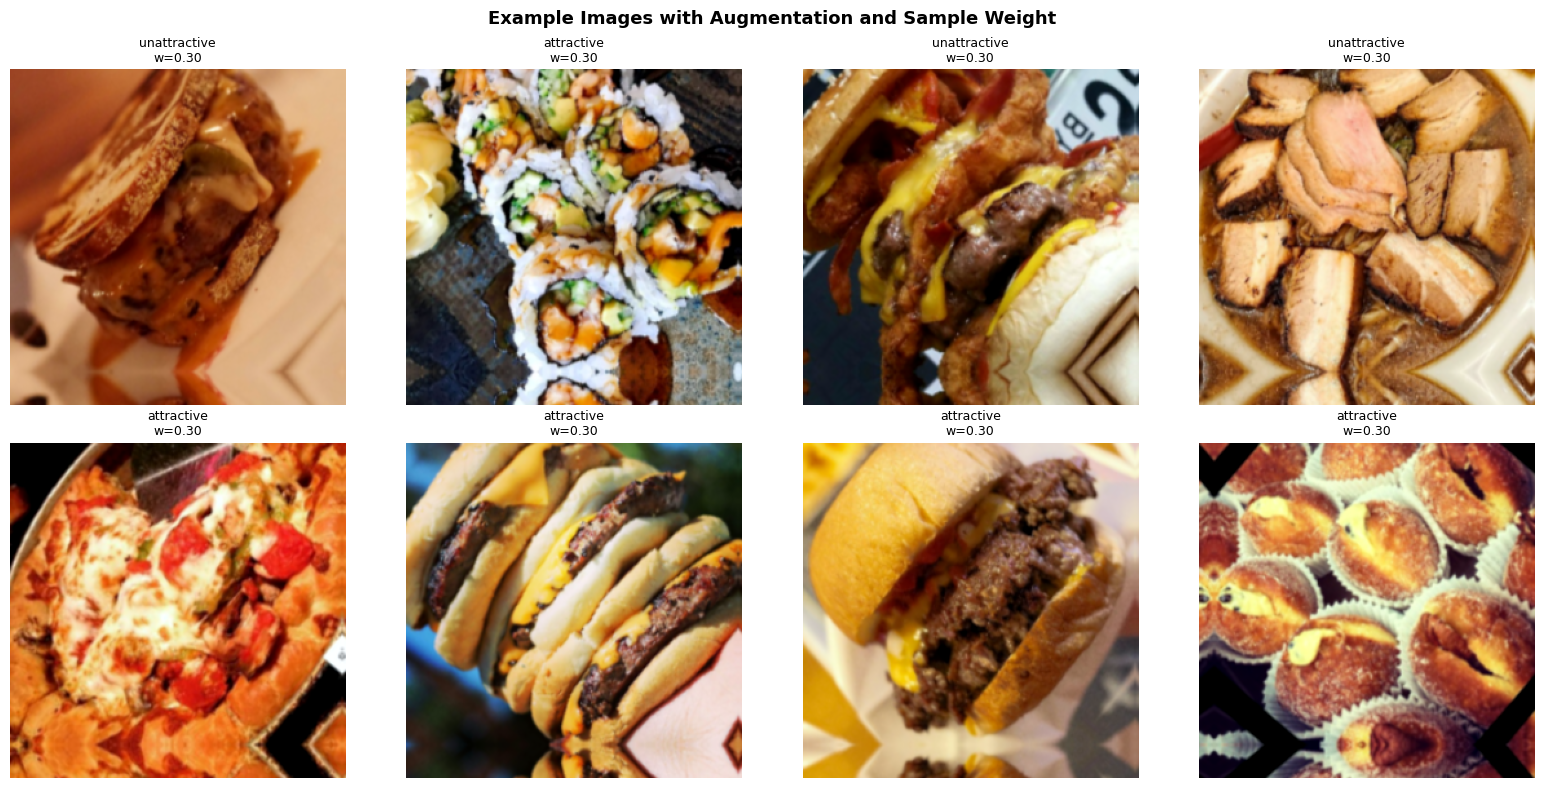

✓ บันทึก sample_augmented.png


In [11]:
# Augmentation layers
augmentation_layer = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
], name="augmentation")


def load_and_preprocess(path, label, weight):
    """โหลด → decode → resize → normalize
       (EfficientNetV2S ทำ rescaling เองภายใน ถ้า include_preprocessing=True)
    """
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)  # EfficientNetV2S จัดการ [0,255] เอง
    return img, label, weight


def make_dataset(directory, df_source=None, batch_size=BATCH_SIZE, training=True):
    """
    สร้าง tf.data.Dataset จากโฟลเดอร์ที่มี sub-folder ชื่อ class
    (attractive / unattractive)
    
    df_source: ใช้สำหรับ map sample_weight ถ้ามี (optional)
    """
    class_names = sorted(os.listdir(directory))  # ['attractive', 'unattractive']
    label_map   = {c: i for i, c in enumerate(class_names)}

    paths, labels, weights = [], [], []
    
    # สร้าง weight lookup ถ้ามี df_source
    weight_lookup = {}
    if df_source is not None:
        for _, row in df_source.iterrows():
            new_name = f"{row['source']}_{row['image_name']}"
            weight_lookup[new_name] = float(row['sample_weight'])

    for cls in class_names:
        cls_dir = os.path.join(directory, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(label_map[cls])
                weights.append(weight_lookup.get(fname, 1.0))

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels, weights)
    )
    if training:
        ds = ds.shuffle(len(paths), seed=42)
    ds = ds.map(
        lambda p, l, w: load_and_preprocess(p, l, w),
        num_parallel_calls=AUTOTUNE
    )
    if training:
        ds = ds.map(
            lambda img, lbl, w: (augmentation_layer(img, training=True), lbl, w),
            num_parallel_calls=AUTOTUNE
        )
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds, class_names, len(paths)


# ทดสอบสร้าง dataset
train_ds, CLASS_NAMES, N_TRAIN = make_dataset(TRAIN_DIR, df_source=train_df, training=True)
val_ds,   _,           N_VAL   = make_dataset(VAL_DIR,   df_source=val_df,   training=False)

print(f"Class names   : {CLASS_NAMES}")
print(f"Train size    : {N_TRAIN} | Val size : {N_VAL}")
print(f"Train batches : {len(train_ds)} | Val batches : {len(val_ds)}")

# แสดงตัวอย่างรูป
sample_batch = next(iter(train_ds))
sample_imgs, sample_lbls, sample_ws = sample_batch

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i >= len(sample_imgs): break
    ax.imshow((sample_imgs[i].numpy() / 255.0).clip(0, 1))
    ax.set_title(f"{CLASS_NAMES[sample_lbls[i].numpy()]}\nw={sample_ws[i]:.2f}", fontsize=9)
    ax.axis('off')
plt.suptitle("Example Images with Augmentation and Sample Weight", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'sample_augmented.png'), dpi=100, bbox_inches='tight')
plt.show()
print("✓ บันทึก sample_augmented.png")

## 7. สร้างโมเดล EfficientNetV2M

Architecture: **ImageNet Pretrained Backbone → Custom Head**
```
Input (260×260×3)
  → EfficientNetV2M (frozen ตอน Phase 1)
  → GlobalAveragePooling2D
  → Dense(256, swish) + BN + Dropout(0.4) + L2
  → Dense(128, swish) + BN + Dropout(0.3) + L2
  → Dense(2, softmax) → attractive / unattractive
```
**Anti-Overfitting ที่ใช้:** Dropout, BatchNorm, L2, Label Smoothing, Cosine Decay, EarlyStopping, Data Augmentation


In [12]:
def build_model(learning_rate=1e-3):
    base = EfficientNetV2M(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # ── Data Augmentation (เฉพาะตอน training=True) ──────────────────
    augment = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.1),
        layers.RandomContrast(0.1),
    ], name="augmentation")

    x = augment(inputs)          # ✅ Keras จัดการ training flag อัตโนมัติ
    x = base(x, training=False)  # backbone ไม่ update BN stats
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='swish',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation='swish',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(N_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="food_attractiveness_v3")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
        weighted_metrics=['accuracy']
    )
    return model, base

model, base_model = build_model(learning_rate=1e-3)
model.summary()

Model: "food_attractiveness_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-m (Functional)   │ (None, 9, 9, 1280)     │    53,150,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,513,014 (204.14 MB)

 Trainable params: 361,858 (1.38 MB)

 Non-trainable params: 53,151,156 (202.76 MB)

## 7.5 (Optional) Resume — โหลด Checkpoint มาเทรนต่อ

> ใช้เมื่อ **หยุดการเทรนกลางคัน** และอยากเทรนต่อจากจุดที่ค้างไว้
> - ถ้าหยุดระหว่าง **Phase 1** → โหลดแล้วรัน Cell Phase 1 ใหม่
> - ถ้าหยุดระหว่าง **Phase 2** → โหลดแล้วรัน Cell Phase 2 ใหม่
> - ถ้าไม่ได้หยุดกลางคัน → **ข้าม cell นี้ไปได้เลย**


In [13]:
# ══════════════════════════════════════════════════════════════════
# !! รันเฉพาะเมื่อต้องการเทรนต่อจาก checkpoint !!
# !! ถ้าเพิ่งเริ่มเทรนใหม่ → ข้าม cell นี้ไปได้เลย !!
# ══════════════════════════════════════════════════════════════════

import os

checkpoint_path = os.path.join(MODEL_DIR, 'best_model.keras')

if os.path.exists(checkpoint_path):
    model = keras.models.load_model(checkpoint_path)
    # ดึง base_model สำหรับ Phase 2 fine-tuning
    base_model = next(l for l in model.layers
                      if isinstance(l, tf.keras.Model) and 'efficientnet' in l.name.lower())
    print(f'✓ โหลด checkpoint สำเร็จ: {checkpoint_path}')
    print(f'  Layers: {len(model.layers)}')
    print(f'  Trainable params: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}')
    print()
    print('📌 เทรนต่อได้เลย — รัน Cell Phase 1 หรือ Phase 2 ที่ค้างไว้')
else:
    print(f'⚠  ไม่พบ checkpoint ที่: {checkpoint_path}')
    print('   ตรวจสอบ MODEL_DIR หรือเริ่มเทรนใหม่จาก Cell 7 แทน')


✓ โหลด checkpoint สำเร็จ: /home/besstsu/Documents/MachineVision/models/best_model.keras
  Layers: 11
  Trainable params: 32,127,846

📌 เทรนต่อได้เลย — รัน Cell Phase 1 หรือ Phase 2 ที่ค้างไว้


## 8. Phase 1 — เทรน Head (Backbone ถูก Freeze)

เทรนเฉพาะ classification head ก่อน — backbone ยังคง weights จาก ImageNet
- LR: 1e-3 (Cosine Decay)
- Epochs: 50 (มี EarlyStopping)
- ModelCheckpoint บันทึก `best_model.keras` อัตโนมัติ


In [ ]:
checkpoint_path = os.path.join(MODEL_DIR, 'best_model.keras')

callbacks_phase1 = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=6,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.CSVLogger(
        os.path.join(MODEL_DIR, 'training_log_phase1.csv')
    ),
]

print("="*70)
print(f"Phase 1: Train Head | EPOCHS={FINAL_EPOCHS} | LR=1e-3")
print("="*70)

# Dataset ที่มี sample_weight
# tf.data ใช้ tuple (inputs, labels, sample_weights)
train_ds_weighted, _, _ = make_dataset(TRAIN_DIR, df_source=train_df, training=True)
val_ds_weighted,   _, _ = make_dataset(VAL_DIR,   df_source=val_df,   training=False)

history = model.fit(
    train_ds_weighted,
    epochs=FINAL_EPOCHS,
    validation_data=val_ds_weighted,
    callbacks=callbacks_phase1,
    verbose=1,
)

best_p1_acc = max(history.history['val_accuracy'])
print(f"\n✓ Phase 1 เสร็จสิ้น! Best val_accuracy = {best_p1_acc:.4f}")

Phase 1: Train Head | EPOCHS=20 | LR=1e-3
Epoch 1/20


E0000 00:00:1773255240.385261   84567 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/food_attractiveness_v3_1/efficientnetv2-m_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1773255243.519257   85300 cuda_dnn.cc:461] Loaded cuDNN version 91900


1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9498 - loss: 0.0450 - weighted_accuracy: 0.9501
Epoch 1: val_accuracy improved from None to 0.80538, saving model to /home/besstsu/Documents/MachineVision/models/best_model.keras

Epoch 1: finished saving model to /home/besstsu/Documents/MachineVision/models/best_model.keras
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 325s 260ms/step - accuracy: 0.9510 - loss: 0.0440 - weighted_accuracy: 0.9512 - val_accuracy: 0.8054 - val_loss: 0.2187 - val_weighted_accuracy: 0.7948 - learning_rate: 2.0459e-05
Epoch 2/20
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9654 - loss: 0.0331 - weighted_accuracy: 0.9657
Epoch 2: val_accuracy improved from 0.80538 to 0.80644, saving model to /home/besstsu/Documents/MachineVision/models/best_model.keras

Epoch 2: finished saving model to /home/besstsu/Documents/MachineVision/models/best_model.keras
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 300s 256ms/step - accuracy: 0.9669 - loss: 0.0319 - weighted_accuracy: 0.9

## 9. Phase 2 — Fine-tuning (Unfreeze Top 30% ของ Backbone)

โหลด best model จาก Phase 1 แล้ว unfreeze top layers ของ backbone
- LR: 1e-4 (เล็กลง 10x เพื่อไม่ทำลาย pretrained weights)
- Epochs: 10 (มี EarlyStopping)
- Cosine Decay ลด LR แบบ smooth จนถึง 1e-10


In [ ]:
print("="*70)
print(f"Phase 2: Fine-tuning | EPOCHS={FINETUNE_EPOCHS} | LR=1e-4")
print("="*70)

# Unfreeze 30% layer ท้ายของ backbone
base_model.trainable = True
total_layers = len(base_model.layers)
freeze_until = int(total_layers * 0.70)  # freeze 70% แรก

for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

# ปิด BatchNorm ใน backbone ไม่ให้ update stats
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_cnt = sum(1 for l in base_model.layers if l.trainable)
print(f"Backbone layers: {total_layers} | Frozen: {freeze_until} | Trainable: {trainable_cnt}")

# Compile ใหม่ด้วย LR ต่ำ (สำคัญมากสำหรับ fine-tune)
model.compile(
    keras.optimizers.Adam(
        keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-4,
            decay_steps=FINETUNE_EPOCHS * (N_TRAIN // BATCH_SIZE),
            alpha=1e-6,
        )
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    weighted_metrics=['accuracy']
)

callbacks_phase2 = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # ❌ ลบ ReduceLROnPlateau ออก — ขัดแย้งกับ CosineDecay schedule
    # CosineDecay จัดการ LR decay ให้อยู่แล้ว ไม่ต้องใช้ callback นี้
    keras.callbacks.CSVLogger(
        os.path.join(MODEL_DIR, 'training_log_phase2.csv')
    ),
]

history_fine = model.fit(
    train_ds_weighted,
    epochs=FINETUNE_EPOCHS,
    validation_data=val_ds_weighted,
    callbacks=callbacks_phase2,
    verbose=1,
)

best_p2_acc = max(history_fine.history['val_accuracy'])
print(f"\n✓ Phase 2 เสร็จสิ้น! Best val_accuracy = {best_p2_acc:.4f}")

import json

# บันทึก history ทั้งสอง phase
history_path = os.path.join(MODEL_DIR, 'training_history.json')

history_data = {
    'phase1': {k: [float(v) for v in vals] for k, vals in history.history.items()},
    'phase2': {k: [float(v) for v in vals] for k, vals in history_fine.history.items()},
}

with open(history_path, 'w') as f:
    json.dump(history_data, f, indent=2)

print(f"✓ บันทึก history → {history_path}")

Phase 2: Fine-tuning | EPOCHS=20 | LR=1e-4
Backbone layers: 740 | Frozen: 518 | Trainable: 177
Epoch 1/20


ถ้า history หาย สามารถโหลดจากไฟล์ training_history.json ที่บันทึกไว้แทน:

In [1]:
# โหลด History จาก CSV (ใช้ตอนไม่ต้องเทรนใหม่)
import pandas as pd

class MockHistory:
    def __init__(self, df):
        self.history = {col: df[col].tolist() for col in df.columns}

p1_csv = os.path.join(MODEL_DIR, 'training_log_phase1.csv')
p2_csv = os.path.join(MODEL_DIR, 'training_log_phase2.csv')

if os.path.exists(p1_csv) and os.path.exists(p2_csv):
    history      = MockHistory(pd.read_csv(p1_csv))
    history_fine = MockHistory(pd.read_csv(p2_csv))
    print(f"✓ โหลด history จาก CSV สำเร็จ")
    print(f"  Phase 1 : {len(history.history['accuracy'])} epochs")
    print(f"  Phase 2 : {len(history_fine.history['accuracy'])} epochs")
    print(f"  Best val_acc : {max(history_fine.history['val_accuracy']):.4f}")
else:
    print("⚠ ไม่พบ CSV — กรุณารัน Training ก่อน")

NameError: name 'os' is not defined

## 10. กราฟผลการเทรน

แสดง accuracy และ loss ของ Phase 1 + Phase 2 ต่อกัน
- เส้นแนวตั้งสีแดงแสดงจุดที่เริ่ม Fine-tuning
- ช่วง train vs val ห่างกันมาก = Overfitting


In [ ]:
def merge_history(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history.get(key, [])
    return combined

# ── ตรวจสอบว่า training cell รันเสร็จหรือยัง ──────────────────────
_h1_exists = 'history'      in vars() and history      is not None
_h2_exists = 'history_fine' in vars() and history_fine is not None

if not _h1_exists:
    raise RuntimeError("❌ ไม่พบ 'history' — กรุณารัน Cell Phase 1 Training ให้เสร็จก่อน")

if not _h2_exists:
    raise RuntimeError("❌ ไม่พบ 'history_fine' — กรุณารัน Cell Phase 2 Fine-tune ให้เสร็จก่อน")

# ── Plot ───────────────────────────────────────────────────────────
full_history = merge_history(history, history_fine)
split_epoch  = len(history.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = {'train': '#2196F3', 'val': '#FF5722'}

for ax, metric in [(axes[0], 'accuracy'), (axes[1], 'loss')]:
    ykey  = metric
    vykey = f'val_{metric}'
    ax.plot(full_history[ykey],  color=colors['train'], lw=2, label=f'Train {metric}')
    ax.plot(full_history[vykey], color=colors['val'],   lw=2, label=f'Val {metric}')
    ax.axvline(split_epoch, color='gray', linestyle=':', lw=1.5, label='Fine-tune start')
    ax.set_title(f"Model {metric.capitalize()}", fontweight='bold', fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric.capitalize())
    ax.legend()
    ax.grid(True, alpha=0.3)

best_acc = max(full_history['val_accuracy'])
plt.suptitle(f"Training History — EfficientNetV2M | Best val_acc={best_acc:.4f}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ บันทึก training_history.png")

NameError: name 'history' is not defined

## 11. ประเมินผลโมเดลบน Validation Set

วัดประสิทธิภาพบนข้อมูลที่โมเดลไม่เคยเห็นระหว่างเทรน:
- **Confusion Matrix** — ดูว่า predict ถูก/ผิดแต่ละ class อย่างไร
- **Score Distribution** — ถ้า 2 สีแยกกันชัด = โมเดล generalize ได้ดี


In [2]:
# โหลดโมเดลที่ดีที่สุด
best_model = keras.models.load_model(checkpoint_path)

# ── ประเมินผล ──────────────────────────────────────────────────────────
val_ds_eval, N_VAL, _ = make_dataset(VAL_DIR, training=False)

def strip_weight(img, lbl, *args):
    """ตัด sample_weight ออกก่อน evaluate"""
    return img, lbl

val_ds_no_weight = val_ds_eval.map(strip_weight)

# รับค่า results ทั้งหมด (compile มีหลาย metrics)
results = best_model.evaluate(val_ds_no_weight, verbose=1)
val_loss, val_acc = results[0], results[1]

print(f"\nValidation Accuracy : {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Validation Loss     : {val_loss:.4f}")

# ── เก็บ predictions ─────────────────────────────────────────────────
y_true, y_pred, y_scores = [], [], []

for batch in val_ds_eval:
    imgs  = batch[0]
    lbls  = batch[1]
    preds = best_model.predict(imgs, verbose=0)
    y_true.extend(lbls.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())
    y_scores.extend(preds[:, CLASS_NAMES.index('attractive')].tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
cm     = confusion_matrix(y_true, y_pred)

# ── Plot 2 กราฟ ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# กราฟ 1: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'}, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# กราฟ 2: Score Distribution
attr_idx  = CLASS_NAMES.index('attractive')
unatt_idx = CLASS_NAMES.index('unattractive')
scores_attr  = [s for s, l in zip(y_scores, y_true) if l == attr_idx]
scores_unatt = [s for s, l in zip(y_scores, y_true) if l == unatt_idx]
axes[1].hist(scores_attr,  bins=30, alpha=0.65, color='#4CAF50', label='True: attractive')
axes[1].hist(scores_unatt, bins=30, alpha=0.65, color='#F44336', label='True: unattractive')
axes[1].axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Decision boundary (0.5)')
axes[1].set_title('Score Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Attractiveness Score (0=unattractive, 1=attractive)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle(f'ผลการประเมิน — Validation Accuracy: {val_acc:.2%}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print("="*60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
print(f"\n✓ บันทึก evaluation.png ที่ {MODEL_DIR}")


NameError: name 'keras' is not defined

## 12. ทดสอบความสอดคล้องกับ Questionnaire

เอาคู่รูปจาก Questionnaire มาให้โมเดลทำนาย แล้วเทียบว่าตรงกับที่คนโหวตไหม
- ถ้า accuracy > 65% ถือว่าโมเดลเรียนรู้รสนิยมมนุษย์ได้
- weighted accuracy คำนวณโดยให้น้ำหนักคู่ที่คนโหวตแน่นอนมากกว่า


In [ ]:
print("วิเคราะห์ความสอดคล้องกับ Questionnaire (30 คู่แรก)...")
print("="*70)

df_quest_eval = pd.read_csv(QUEST_CSV_PATH)

def score_image(img_path):
    """คืน attractive probability ของรูปภาพหนึ่งรูป"""
    try:
        img = tf.io.read_file(img_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = tf.cast(img, tf.float32)
        img = tf.expand_dims(img, 0)
        pred = best_model.predict(img, verbose=0)[0]
        attractive_idx = CLASS_NAMES.index('attractive')
        return float(pred[attractive_idx])
    except Exception:
        return None

agreements, total = 0, 0
weighted_agreements, weighted_total = 0.0, 0.0
details = []

for _, row in df_quest_eval.head(30).iterrows():
    p1 = os.path.join(QUEST_IMAGES_DIR, row['Image 1'])
    p2 = os.path.join(QUEST_IMAGES_DIR, row['Image 2'])
    if not (os.path.exists(p1) and os.path.exists(p2)):
        continue
    s1, s2 = score_image(p1), score_image(p2)
    if s1 is None or s2 is None:
        continue
    pred_win  = 1 if s1 > s2 else 2
    true_win  = int(row['Winner'])
    correct   = pred_win == true_win
    vote_conf = abs(row['Num Vote 1'] - row['Num Vote 2']) / row['Num Voter']

    agreements       += int(correct)
    total            += 1
    weighted_agreements += int(correct) * vote_conf
    weighted_total      += vote_conf

    details.append({'pair'     : f"{row['Image 1']} vs {row['Image 2']}",
                    'true'     : true_win,
                    'pred'     : pred_win,
                    's1'       : s1,
                    's2'       : s2,
                    'ok'       : correct,
                    'conf'     : vote_conf})

print(f"\nความสอดคล้อง (accuracy)         : {agreements}/{total} ({agreements/total:.2%})")
if weighted_total > 0:
    print(f"ความสอดคล้อง (weighted by conf)  : {weighted_agreements/weighted_total:.2%}")

print("\nตัวอย่าง 10 คู่แรก:")
for d in details[:10]:
    mark = '✓' if d['ok'] else '✗'
    print(f" {mark} {d['pair'][:45]:45s} True={d['true']} Pred={d['pred']} "
          f"Scores=({d['s1']:.3f}, {d['s2']:.3f}) conf={d['conf']:.2f}")

## 13. บันทึกโมเดลและ Config

บันทึกไฟล์ที่จำเป็นสำหรับ deployment ลงใน `models/`:
- `food_aesthetic_v14.keras` — โมเดลพร้อม inference
- `class_names.json` — ลำดับ class (สำคัญมาก อย่าลบ)
- `model_config.json` — config และ metrics สรุปผลการเทรน
- `evaluation.png` — กราฟประเมินผล


In [ ]:
final_path = os.path.join(MODEL_DIR, 'food_aesthetic_v14.keras')
best_model.save(final_path)
print(f"✓ บันทึกโมเดล: {final_path}")

# บันทึก class names
with open(os.path.join(MODEL_DIR, 'class_names.json'), 'w', encoding='utf-8') as f:
    json.dump(CLASS_NAMES, f, indent=2)

# บันทึก config รวม
config = {
    'img_size'               : IMG_SIZE,
    'n_classes'              : N_CLASSES,
    'class_names'            : CLASS_NAMES,
    'final_epochs'           : FINAL_EPOCHS,
    'finetune_epochs'        : FINETUNE_EPOCHS,
    'batch_size'             : BATCH_SIZE,
    'learning_rate_phase1'   : 1e-3,
    'learning_rate_phase2'   : 1e-4,
    'weight_questionnaire'   : WEIGHT_QUEST,
    'weight_instagram'       : WEIGHT_INSTA,
    'weight_auto_label'      : WEIGHT_AUTO,
    'n_train'                : int(N_TRAIN),
    'n_val'                  : int(N_VAL),
    'best_val_accuracy'      : float(max(full_history['val_accuracy'])),
    'data_sources'           : {
        'questionnaire'      : int(len(df_quest_img)),
        'instagram'          : int(len(df_insta_img)),
        'auto_label'         : int(len(df_auto)),
    }
}

with open(os.path.join(MODEL_DIR, 'model_config.json'), 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("\n" + "="*70)
print("🎉 ทุกขั้นตอนเสร็จสมบูรณ์!")
print("="*70)
print(f"ไฟล์ใน {MODEL_DIR}:")
for fn in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(os.path.join(MODEL_DIR, fn))
    print(f"  {'%.1f KB' % (size/1024):>10}  {fn}")

## 14. ฟังก์ชัน Inference — ทำนายความน่ากิน

ฟังก์ชันสำหรับใช้งานจริง:
- `predict_attractiveness(path)` — ทำนายรูปเดียว คืน score 0–1
- `compare_food_images(path1, path2)` — เปรียบเทียบ 2 รูป แสดงกราฟ winner

ฟังก์ชันเหล่านี้ถูกใช้ใน `app.py` (Streamlit) ด้วย


In [ ]:
def predict_attractiveness(image_path: str, model=None) -> dict:
    """
    ทำนายความน่ากินของรูปอาหาร 1 รูป
    คืนค่า: dict ที่มี label, confidence, all_probs
    """
    if model is None:
        model = best_model
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = tf.expand_dims(img, 0)
    probs = model.predict(img, verbose=0)[0]
    idx   = int(np.argmax(probs))
    return {
        'label'     : CLASS_NAMES[idx],
        'confidence': float(probs[idx]),
        'all_probs' : {c: float(probs[i]) for i, c in enumerate(CLASS_NAMES)}
    }


def compare_food_images(path1: str, path2: str, model=None):
    """เปรียบเทียบความน่ากินของ 2 รูปภาพ และแสดงผล"""
    r1 = predict_attractiveness(path1, model)
    r2 = predict_attractiveness(path2, model)
    s1 = r1['all_probs']['attractive']
    s2 = r2['all_probs']['attractive']
    winner = "Image 1" if s1 >= s2 else "Image 2"

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, path, score, other_score in [
        (axes[0], path1, s1, s2),
        (axes[1], path2, s2, s1),
    ]:
        img_disp = plt.imread(path)
        ax.imshow(img_disp)
        lbl = "Image 1" if path == path1 else "Image 2"
        ax.set_title(f"{lbl}\nScore: {score:.3f}", fontweight='bold', fontsize=12)
        ax.axis('off')
        color = 'green' if score >= other_score else 'gray'
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(4)

    bars = axes[2].barh(['Image 1', 'Image 2'], [s1, s2],
                        color=['#4CAF50' if s1 >= s2 else '#9E9E9E',
                               '#4CAF50' if s2 > s1  else '#9E9E9E'],
                        alpha=0.8, height=0.5)
    for bar, val in zip(bars, [s1, s2]):
        axes[2].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=12, fontweight='bold')
    axes[2].set_xlim(0, 1)
    axes[2].set_xlabel('Attractiveness Score', fontsize=11)
    axes[2].set_title(f'🏆 Winner: {winner}', fontsize=13, fontweight='bold')
    axes[2].grid(True, alpha=0.3, axis='x')

    plt.suptitle('Food Attractiveness Comparison — EfficientNetV2M',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f"\n🏆 Winner: {winner}")
    print(f"   Image 1: {s1:.4f} | Image 2: {s2:.4f}")
    return r1, r2


print("✓ ฟังก์ชัน predict_attractiveness และ compare_food_images พร้อมใช้")
print("\nตัวอย่างการใช้งาน:")
print("  result = predict_attractiveness('path/to/image.jpg')")
print("  compare_food_images('img1.jpg', 'img2.jpg')")

## 15. โหลดโมเดลที่เทรนไว้แล้ว (ไม่ต้อง retrain)

ถ้าเทรนเสร็จแล้วและอยากใช้งานครั้งถัดไป — uncomment โค้ดด้านล่างได้เลย
ไม่ต้องรัน cell 1–13 ใหม่ทั้งหมด


In [ ]:
# โค้ดสำหรับโหลดโมเดลในครั้งถัดไป (ไม่ต้อง train ใหม่)
# uncomment บรรทัดด้านล่างเพื่อใช้งาน

# MODEL_PATH = os.path.join(BASE_PATH, 'models', 'food_aesthetic_v14.keras')
# CLASS_JSON = os.path.join(BASE_PATH, 'models', 'class_names.json')
#
# loaded_model = keras.models.load_model(MODEL_PATH)
# with open(CLASS_JSON) as f:
#     CLASS_NAMES = json.load(f)
#
# result = predict_attractiveness('path/to/your_image.jpg', model=loaded_model)
# print(result)

print('✓ คำแนะนำสำหรับโหลดโมเดลแสดงข้างบนแล้ว (uncomment เพื่อใช้งาน)')
print(f'   MODEL_PATH จะอยู่ที่: {os.path.join(BASE_PATH, "models", "food_aesthetic_v14.keras")}')


ตัวเทียบอาหาร 2 ภาพ

In [2]:
import ctypes, os, json
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# โหลด CUDA (ถ้าใช้ GPU)
_CUDA_LIBS = [
    "/usr/lib/wsl/lib/libcuda.so.1",
    "/home/besstsu/Documents/MachineVision/.venv/lib/python3.12/site-packages/nvidia/cudnn/lib/libcudnn.so.9",
]
for lib in _CUDA_LIBS:
    try: ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
    except: pass

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

BASE_PATH  = '/home/besstsu/Documents/MachineVision'
IMG_SIZE   = 260
CLASS_NAMES = None  # จะโหลดจาก json

print("✓ Import เรียบร้อย")
# ── โหลดโมเดล (ถ้า restart WSL แล้ว) ──────────────────────────────
MODEL_PATH  = os.path.join(BASE_PATH, 'models', 'food_aesthetic_v14.keras')
CLASS_JSON  = os.path.join(BASE_PATH, 'models', 'class_names.json')

loaded_model = keras.models.load_model(MODEL_PATH)
with open(CLASS_JSON) as f:
    CLASS_NAMES = json.load(f)

print("✓ โหลดโมเดลสำเร็จ")

✓ Import เรียบร้อย
✓ โหลดโมเดลสำเร็จ


✓ ฟังก์ชันพร้อมใช้งาน


/tmp/ipykernel_8829/2708814711.py:52: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/besstsu/Documents/MachineVision/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


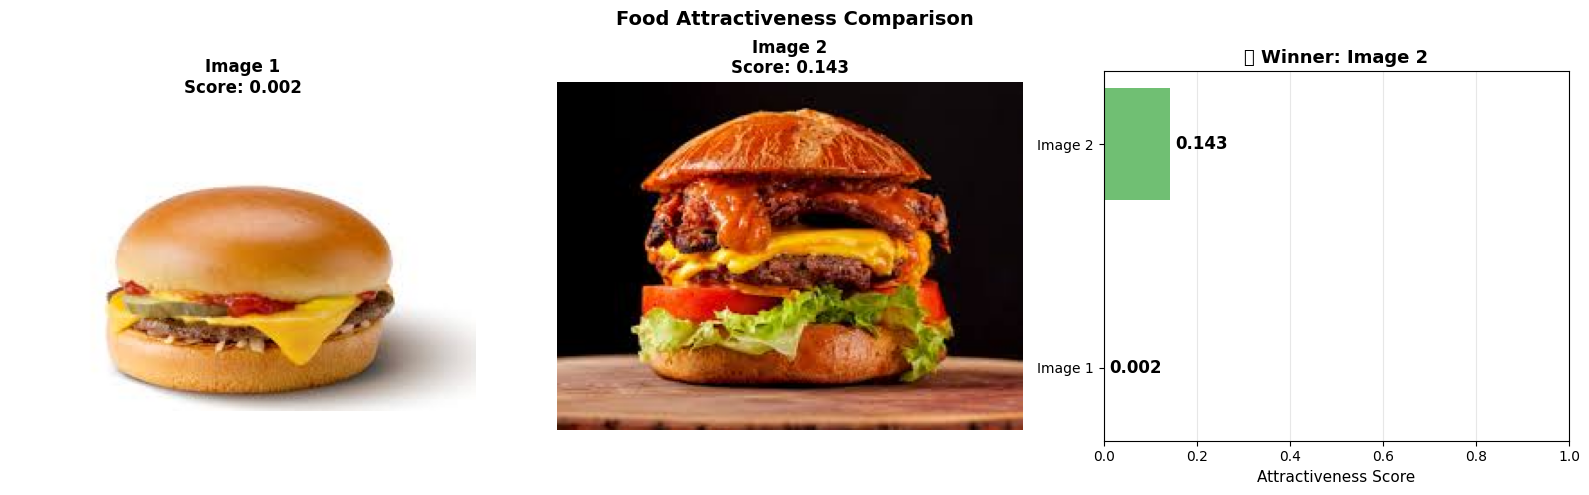


🏆 Winner: Image 2
   Image 1: 0.0016 | Image 2: 0.1431


In [3]:
# ── เปรียบเทียบ 2 ภาพ ──────────────────────────────────────────────
IMG1 = '/home/besstsu/Documents/MachineVision/datafortest/download.jpg'   # ← เปลี่ยน path
IMG2 = '/home/besstsu/Documents/MachineVision/datafortest/images (2).jpg'   # ← เปลี่ยน path
def predict_attractiveness(image_path: str, model=None) -> dict:
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = tf.expand_dims(img, 0)
    probs = model.predict(img, verbose=0)[0]
    idx   = int(np.argmax(probs))
    return {
        'label'     : CLASS_NAMES[idx],
        'confidence': float(probs[idx]),
        'all_probs' : {c: float(probs[i]) for i, c in enumerate(CLASS_NAMES)}
    }

def compare_food_images(path1: str, path2: str, model=None):
    r1 = predict_attractiveness(path1, model)
    r2 = predict_attractiveness(path2, model)
    s1 = r1['all_probs']['attractive']
    s2 = r2['all_probs']['attractive']
    winner = "Image 1" if s1 >= s2 else "Image 2"

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, path, score, other_score in [
        (axes[0], path1, s1, s2),
        (axes[1], path2, s2, s1),
    ]:
        img_disp = plt.imread(path)
        ax.imshow(img_disp)
        lbl = "Image 1" if path == path1 else "Image 2"
        ax.set_title(f"{lbl}\nScore: {score:.3f}", fontweight='bold', fontsize=12)
        ax.axis('off')
        color = 'green' if score >= other_score else 'gray'
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(4)

    bars = axes[2].barh(['Image 1', 'Image 2'], [s1, s2],
                        color=['#4CAF50' if s1 >= s2 else '#9E9E9E',
                               '#4CAF50' if s2 > s1  else '#9E9E9E'],
                        alpha=0.8, height=0.5)
    for bar, val in zip(bars, [s1, s2]):
        axes[2].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=12, fontweight='bold')
    axes[2].set_xlim(0, 1)
    axes[2].set_xlabel('Attractiveness Score', fontsize=11)
    axes[2].set_title(f'🏆 Winner: {winner}', fontsize=13, fontweight='bold')
    axes[2].grid(True, alpha=0.3, axis='x')

    plt.suptitle('Food Attractiveness Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f"\n🏆 Winner: {winner}")
    print(f"   Image 1: {s1:.4f} | Image 2: {s2:.4f}")
    return r1, r2

print("✓ ฟังก์ชันพร้อมใช้งาน")
r1, r2 = compare_food_images(IMG1, IMG2, model=loaded_model)